# Practice 3: Customer Clustering - Bước 7.1: Phân tích chân dung khách hàng từ cụm K-Medoids

---

Do thuật toán **K-Medoids** hoạt động độc lập và đạt hiệu năng Silhouette Score tốt hơn ở **K = 4** so với K = 3 của K-Means, chúng ta tiến hành khảo sát và vẽ chân dung khách hàng trên kết quả phân cụm này để phục vụ chiến dịch marketing và định vị dòng xe ô tô phù hợp.

## 1. Import các thư viện và tải dữ liệu

Chúng ta tải dữ liệu gốc đã làm sạch `Train_cleaned.csv` và nhãn phân cụm đại diện K-Medoids từ Scratch (`kmedoids_labels.npy`). Do triết lý không chia Train/Val để bảo toàn không gian mật độ, việc ghép nhãn sẽ thực hiện trực tiếp trên toàn bộ 6,664 dòng dữ liệu.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_theme(style='whitegrid', palette='muted')

# 1. Tải dữ liệu gốc sạch
df_raw = pd.read_csv('../data/processed/Train_cleaned.csv')

# 2. Tải nhãn K-Medoids từ Scratch
kmedoids_labels = np.load('../models/kmedoids_labels.npy')

# 3. Ghép nhãn trực tiếp vào tập dữ liệu đầy đủ
df_kmed = df_raw.copy()
df_kmed['Cluster'] = kmedoids_labels

print(f'Kích thước tập dữ liệu được ghép nhãn K-Medoids: {df_kmed.shape}')
print('Số lượng mẫu trong từng cụm K-Medoids:')
print(df_kmed['Cluster'].value_counts().sort_index())

Kích thước tập dữ liệu được ghép nhãn K-Medoids: (6664, 11)
Số lượng mẫu trong từng cụm K-Medoids:
Cluster
0    2258
1    1283
2    1609
3    1514
Name: count, dtype: int64


## 2. Thống kê đặc trưng số học theo cụm

Khảo sát các biến định lượng `Age`, `Work_Experience`, và `Family_Size`.

Age        Work_Experience        Family_Size       
              mean median            mean median        mean median
Cluster                                                            
0        51.098317   50.0        2.269708    1.0    2.769708    2.0
1        27.608730   26.0        1.857366    1.0    3.770850    4.0
2        50.310131   48.0        2.602859    1.0    2.673089    2.0
3        37.931968   37.0        3.590489    1.0    2.178996    2.0

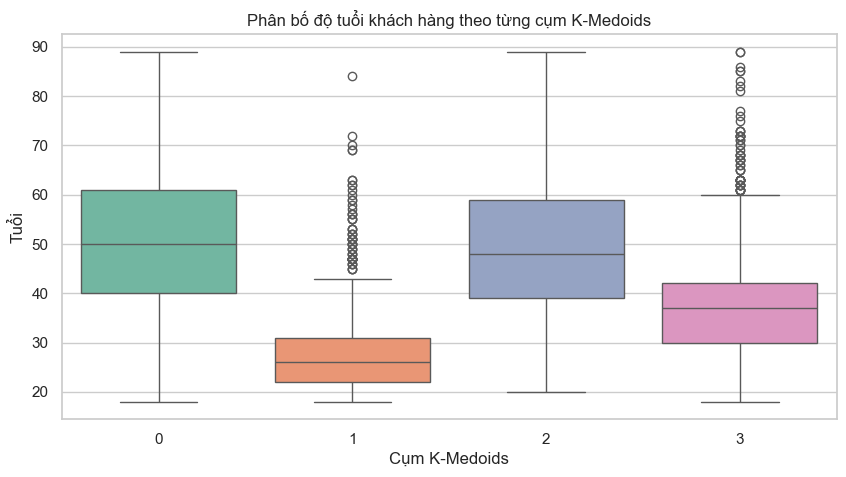

In [2]:
numerical_stats = df_kmed.groupby('Cluster')[['Age', 'Work_Experience', 'Family_Size']].agg(['mean', 'median'])
display(numerical_stats)

# Vẽ phân bố độ tuổi của 4 cụm
plt.figure(figsize=(10, 5))
sns.boxplot(x='Cluster', y='Age', data=df_kmed, hue='Cluster', palette='Set2', legend=False)
plt.title('Phân bố độ tuổi khách hàng theo từng cụm K-Medoids')
plt.xlabel('Cụm K-Medoids')
plt.ylabel('Tuổi')
plt.show()

## 3. Trực quan hóa tỷ lệ các đặc trưng nhân khẩu học theo cụm (Có gắn số liệu % cụ thể)

Chúng ta vẽ biểu đồ so sánh phân bố tỷ lệ phần trăm các đặc trưng phân loại quan trọng chéo theo cụm, hiển thị rõ số liệu tỷ lệ % trực tiếp trên cột.

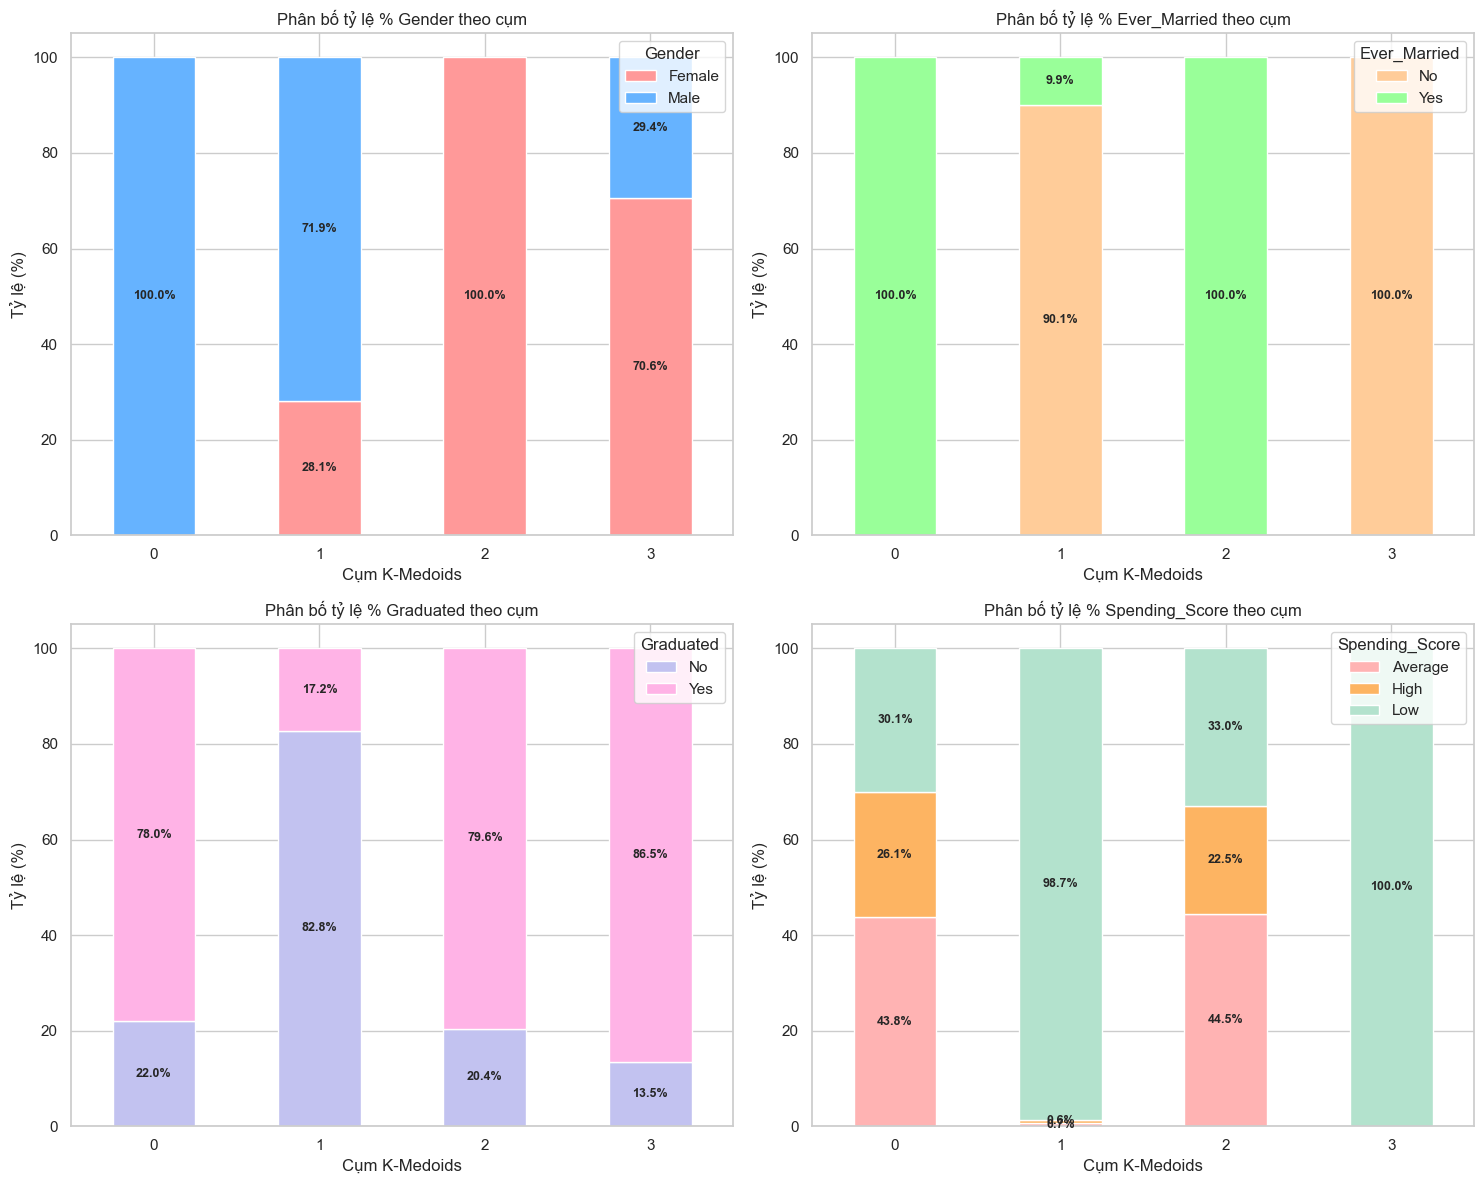

In [3]:
features = ['Gender', 'Ever_Married', 'Graduated', 'Spending_Score']
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.ravel()

# Bảng màu tùy chỉnh hài hòa
colors_dict = {
    'Gender': ['#ff9999', '#66b3ff'],
    'Ever_Married': ['#ffcc99', '#99ff99'],
    'Graduated': ['#c2c2f0', '#ffb3e6'],
    'Spending_Score': ['#ffb3b3', '#fdb462', '#b3e2cd']
}

for idx, col in enumerate(features):
    cross_dist = pd.crosstab(df_kmed['Cluster'], df_kmed[col], normalize='index') * 100
    ax = axes[idx]
    cross_dist.plot(kind='bar', stacked=True, ax=ax, color=colors_dict[col])
    ax.set_title(f'Phân bố tỷ lệ % {col} theo cụm')
    ax.set_xlabel('Cụm K-Medoids')
    ax.set_ylabel('Tỷ lệ (%)')
    ax.legend(title=col)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
    
    # Thêm nhãn số liệu phần trăm trực tiếp trên cột
    for container in ax.containers:
        labels = [f'{v.get_height():.1f}%' if v.get_height() > 0 else '' for v in container]
        ax.bar_label(container, labels=labels, label_type='center', fontsize=9, weight='bold')

plt.tight_layout()
plt.show()

## 4. Trực quan hóa đặc trưng nổi trội của các cụm (Có hiển thị nhãn giá trị)

Chúng ta vẽ biểu đồ so sánh sự khác biệt lớn về Nghề nghiệp (`Profession`) và Mức độ chi tiêu (`Spending_Score`) giữa 4 cụm khách hàng.

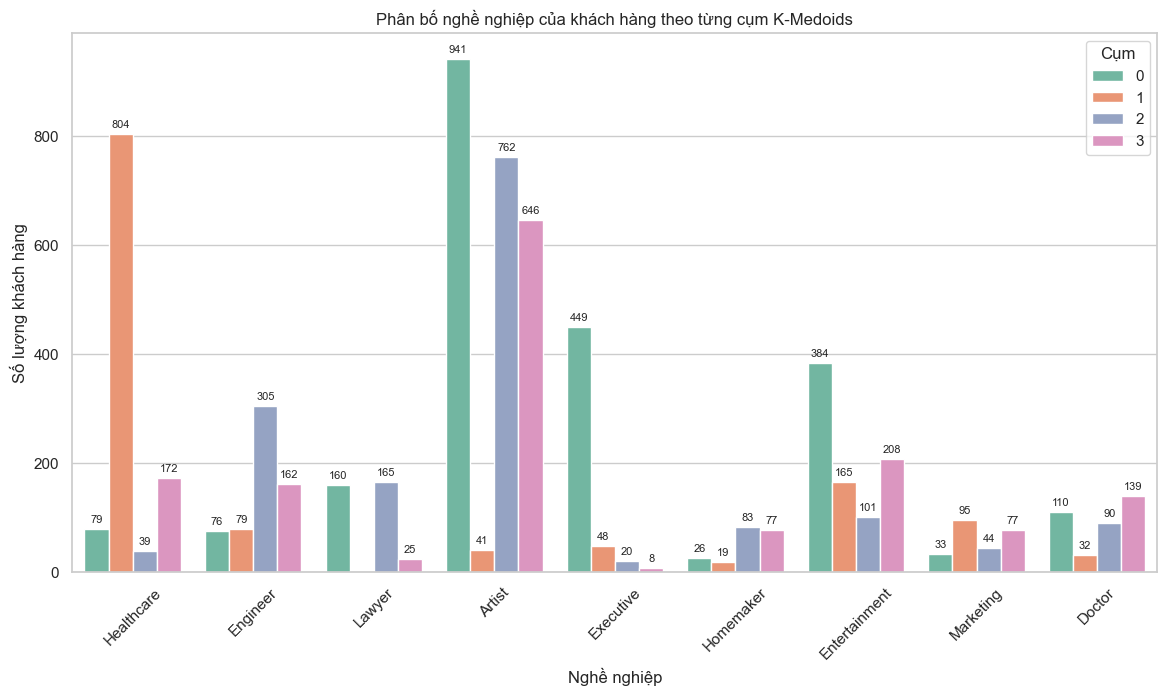

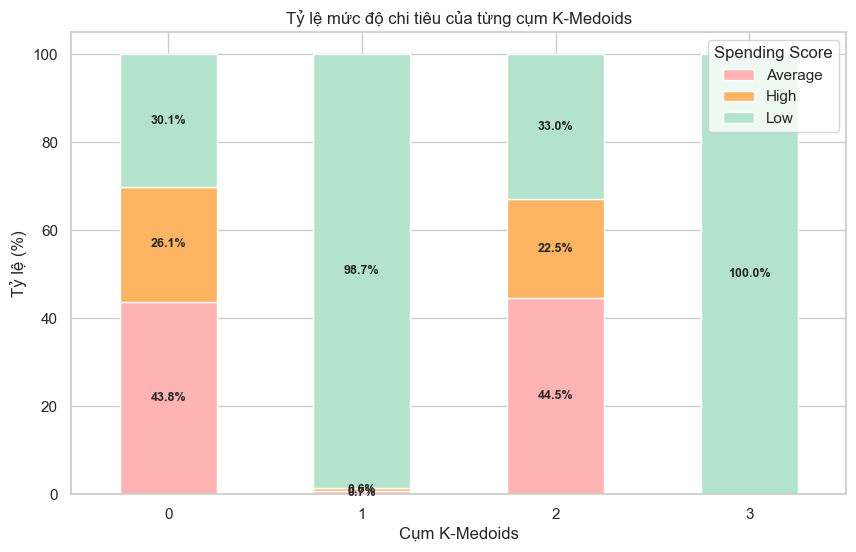

In [4]:
# 4.1. Phân bố Nghề nghiệp theo cụm
plt.figure(figsize=(14, 7))
ax1 = sns.countplot(x='Profession', hue='Cluster', data=df_kmed, palette='Set2')
plt.title('Phân bố nghề nghiệp của khách hàng theo từng cụm K-Medoids')
plt.xlabel('Nghề nghiệp')
plt.ylabel('Số lượng khách hàng')
plt.xticks(rotation=45)
plt.legend(title='Cụm')

# Thêm nhãn số lượng mẫu trên cột
for container in ax1.containers:
    ax1.bar_label(container, fontsize=8, padding=3)
plt.show()

# 4.2. Phân bố Mức chi tiêu theo cụm
spending_dist = pd.crosstab(df_kmed['Cluster'], df_kmed['Spending_Score'], normalize='index') * 100
plt.figure(figsize=(10, 6))
ax2 = plt.gca()
spending_dist.plot(kind='bar', stacked=True, ax=ax2, color=['#ffb3b3', '#fdb462', '#b3e2cd'])
plt.title('Tỷ lệ mức độ chi tiêu của từng cụm K-Medoids')
plt.xlabel('Cụm K-Medoids')
plt.ylabel('Tỷ lệ (%)')
plt.xticks(rotation=0)
plt.legend(title='Spending Score')

# Thêm nhãn số liệu % trên cột chi tiêu
for container in ax2.containers:
    labels = [f'{v.get_height():.1f}%' if v.get_height() > 0 else '' for v in container]
    ax2.bar_label(container, labels=labels, label_type='center', fontsize=9, weight='bold')

plt.show()

## 5. Định hình chân dung khách hàng mua ô tô (Concise Automobile Customer Personas)

Dựa trên kết quả phân tích số liệu ở trên, chúng ta định hình chân dung 4 nhóm khách hàng K-Medoids cụ thể như sau:

* **Cụm 0: Nam giới lớn tuổi thành đạt (Đã kết hôn, Trí thức cao)**
  * **Đặc trưng số học**: Tuổi trung bình ~51.1 (lớn nhất) | Gia đình nhỏ (~2.8 người).
  * **Đặc trưng nhân khẩu học**: 100% Nam | 100% Đã kết hôn | 78.0% Tốt nghiệp đại học | Chi tiêu Trung bình hoặc Cao đạt ~70.0%.
  * **Nghề nghiệp**: Artist (41.7%), Executive (19.9%), Entertainment (17.0%).
  * **Dòng xe mục tiêu**: Sedan hạng sang cỡ trung/lớn (Executive Sedan), SUV gia đình cao cấp (Lux SUV).
  * **Chiến lược tiếp thị**: Tập trung quảng bá các thông điệp về vị thế xã hội, trải nghiệm sang trọng và các gói hỗ trợ đặc quyền VIP.

* **Cụm 1: Khách hàng trẻ tuổi mới đi làm (Độc thân, Chi tiêu tối giản)**
  * **Đặc trưng số học**: Tuổi trung bình ~27.6 (trẻ nhất) | Quy mô gia đình lớn (~3.8 người - sống chung với cha mẹ).
  * **Đặc trưng nhân khẩu học**: 71.9% Nam | 90.1% Độc thân | 82.8% Chưa tốt nghiệp đại học | 98.7% Chi tiêu ở mức Thấp (Low).
  * **Nghề nghiệp**: Healthcare (62.7%) (nhóm y tá, kỹ thuật viên y tế trẻ), Entertainment (12.9%), Marketing (7.4%).
  * **Dòng xe mục tiêu**: Xe đô thị cỡ nhỏ giá rẻ (Hatchback hạng A/B, Mini EV).
  * **Chiến lược tiếp thị**: Ưu tiên các chương trình khuyến mãi giảm giá trực tiếp, hỗ trợ trả góp lãi suất 0% cho người mua xe lần đầu.

* **Cụm 2: Phụ nữ trung niên thành đạt (Đã kết hôn, Học vấn cao)**
  * **Đặc trưng số học**: Tuổi trung bình ~50.3 | Quy mô gia đình trung bình (~2.7 người).
  * **Đặc trưng nhân khẩu học**: 100% Nữ | 100% Đã kết hôn | 79.6% Tốt nghiệp đại học | Chi tiêu Trung bình hoặc Cao đạt ~67.0%.
  * **Nghề nghiệp**: Artist (47.4%), Engineer (19.0%), Lawyer (10.3%).
  * **Dòng xe mục tiêu**: SUV đô thị hạng sang cỡ trung, xe Hybrid thân thiện với môi trường.
  * **Chiến lược tiếp thị**: Nhấn mạnh các tính năng an toàn chủ động (ADAS), thiết kế nội thất tinh tế và hiệu năng tiết kiệm năng lượng.

* **Cụm 3: Khách hàng trung niên độc thân tự lập (Học vấn cao, Chi tiêu thông thái)**
  * **Đặc trưng số học**: Tuổi trung bình ~37.9 | Gia đình rất nhỏ (~2.2 người - sống độc lập).
  * **Đặc trưng nhân khẩu học**: 70.6% Nữ | 100% Độc thân | 86.5% Tốt nghiệp đại học (cao nhất) | 100% Chi tiêu mức Thấp (Low).
  * **Nghề nghiệp**: Artist (42.7%), Healthcare (11.4%), Engineer (10.7%), Doctor (9.2%).
  * **Dòng xe mục tiêu**: Crossover năng động (C-SUV), Sedan cỡ C thiết kế hiện đại.
  * **Chiến lược tiếp thị**: Đánh vào yếu tố cá tính, công nghệ kết nối thông minh và giá trị sử dụng tối ưu.